# 00 — Setup e Qualidade de Dados

**Objetivo**: carregar `trusted_municipios`, validar estrutura e gerar o relatório de Data Quality da Etapa 2.

**Inputs**: `trusted_municipios` (BigQuery).

**Outputs**:
- `data/processed/reports/data_quality_report.json`
- `data/processed/figures/00_missing_values_heatmap.png`
- `data/processed/figures/00_municipios_por_uf.png`
- `data/processed/figures/00_populacao_total_distribuicao.png`

In [1]:
# Imports e configuração
import logging

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.utils.bigquery import read_table_to_dataframe
from src.utils.eda import (
    compute_descriptive_stats,
    compute_null_profile,
    plot_distribution,
    save_figure,
    save_json,
)

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

In [2]:
# Constantes
OUTPUT_REPORT = "data_quality_report.json"

## 1. Leitura da base trusted

In [3]:
df = read_table_to_dataframe("trusted_municipios")
logger.info("Linhas: %d, Colunas: %d", df.shape[0], df.shape[1])
df.head()

2026-08-26 12:21:40,445 - INFO - Linhas: 5570, Colunas: 26


,id_municipio,nome_municipio,sigla_uf,nome_uf,nome_regiao,populacao_total,populacao_18_35_pct,populacao_urbana_pct,rendimento_domiciliar_per_capita,escolaridade_ensino_medio_pct,...,volume_depositos,volume_credito,banda_larga_fixa_por_100_hab,idhm,pix_per_capita_12m,agencias_por_100k_hab,depositos_per_capita,credito_per_capita,_extracted_at,_source_url
0,1200401,Rio Branco,AC,Acre,Norte,364756.0,30.953021,93.494007,1436.01,57.803172,...,1.180372e+09,6.269960e+09,27.121267,0.727,181469.432933,4.66065,3236.060199,17189.463101,2026-08-25 11:40:40.996204+00:00,consolidation_script
1,1200179,Capixaba,AC,Acre,Norte,10392.0,26.039261,40.656274,806.69,32.666476,...,0.000000e+00,0.000000e+00,6.338221,0.575,93104.435291,0.00000,0.000000,0.000000,2026-08-25 11:40:40.996204+00:00,consolidation_script
2,1200328,Jordão,AC,Acre,Norte,9222.0,29.635654,39.839514,542.04,32.031924,...,0.000000e+00,0.000000e+00,6.849454,0.469,52279.653216,0.00000,0.000000,0.000000,2026-08-25 11:40:40.996204+00:00,consolidation_script
3,1200336,Mâncio Lima,AC,Acre,Norte,19294.0,29.921219,65.963512,695.90,43.726143,...,0.000000e+00,0.000000e+00,10.825724,0.625,57771.838214,0.00000,0.000000,0.000000,2026-08-25 11:40:40.996204+00:00,consolidation_script
4,1200351,Marechal Thaumaturgo,AC,Acre,Norte,17093.0,30.965892,34.481952,516.91,28.587830,...,0.000000e+00,0.000000e+00,6.390873,0.501,43331.381885,0.00000,0.000000,0.000000,2026-08-25 11:40:40.996204+00:00,consolidation_script


## 2. Volumetria e integridade

In [4]:
assert df.shape[0] == 5570, f"Esperado 5570 municípios, obtido {df.shape[0]}"
assert df["id_municipio"].nunique() == df.shape[0], "id_municipio duplicado"
assert df["id_municipio"].isnull().sum() == 0, "id_municipio nulo"

logger.info("Volumetria OK: %d municípios", df.shape[0])
logger.info("Municípios únicos: %d", df["id_municipio"].nunique())

2026-08-26 12:21:40,565 - INFO - Volumetria OK: 5570 municípios
2026-08-26 12:21:40,569 - INFO - Municípios únicos: 5570


## 3. Perfil de nulos

In [5]:
null_profile = compute_null_profile(df)
display(null_profile)

,coluna,tipo,nulos,pct_nulos
10,domicilios_com_internet_pct,Int64,5570,100.00
19,idhm,float64,6,0.11
0,id_municipio,object,0,0.00
14,pib_per_capita,float64,0,0.00
24,_extracted_at,"datetime64[us, UTC]",0,0.00
23,credito_per_capita,float64,0,0.00
22,depositos_per_capita,float64,0,0.00
21,agencias_por_100k_hab,float64,0,0.00
20,pix_per_capita_12m,float64,0,0.00
18,banda_larga_fixa_por_100_hab,float64,0,0.00


2026-08-26 12:21:48,358 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/figures/00_missing_values_heatmap.png


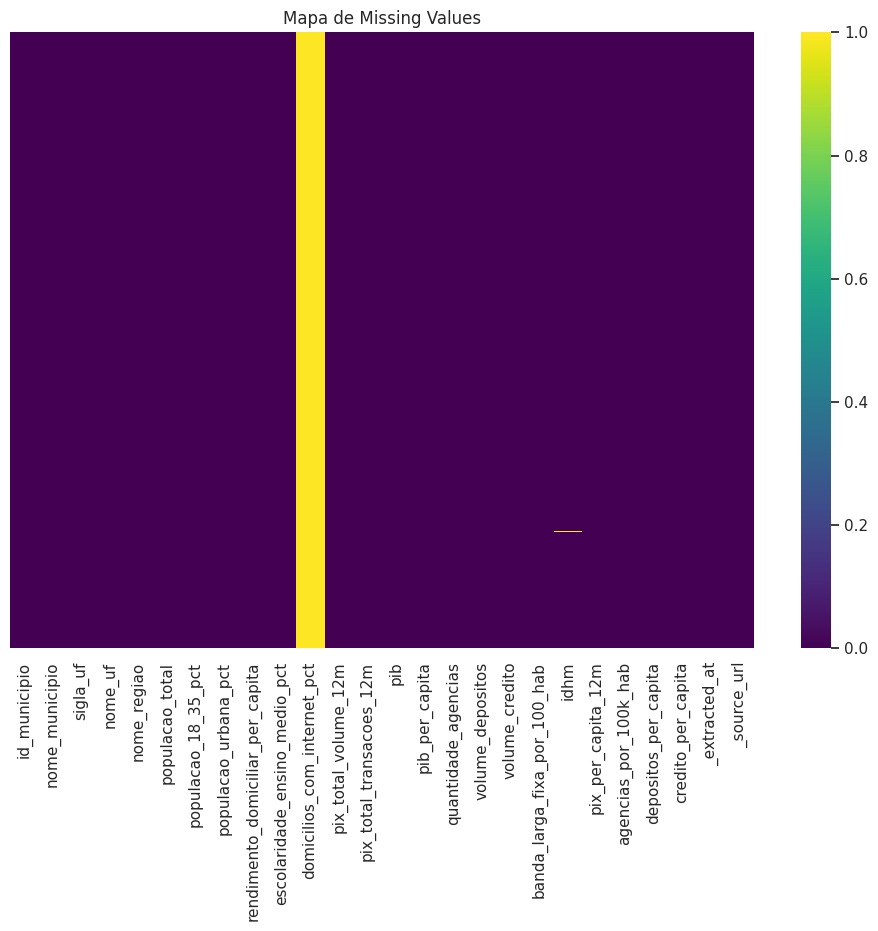

In [6]:
# Heatmap de missing values
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap="viridis", ax=ax)
ax.set_title("Mapa de Missing Values")
save_figure(fig, "00_missing_values_heatmap.png")
plt.show()

## 4. Estatísticas descritivas

In [7]:
desc = compute_descriptive_stats(df)
display(desc)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skewness,kurtosis,iqr,missing_pct
populacao_total,5570.0,36459.740754,206518.731949,833.0,1687.76,2458.45,5228.0,11065.0,24427.25,111869.7,418368.57,11451999.0,37.180725,1838.969646,19199.25,0.00
populacao_18_35_pct,5570.0,25.669324,2.890479,14.358974,18.704506,20.848177,23.840321,25.759947,27.497317,30.145708,32.452789,50.581846,0.143247,1.734782,3.656996,0.00
populacao_urbana_pct,5570.0,69.038879,20.137436,7.330868,22.116393,33.775194,54.114315,70.83455,86.051042,97.446836,99.848755,100.0,-0.38531,-0.724555,31.936726,0.00
rendimento_domiciliar_per_capita,5570.0,1211.587144,493.337884,288.65,509.5969,605.794,772.39,1182.54,1520.3575,2095.023,2608.3642,4299.91,0.863844,1.053486,747.9675,0.00
escolaridade_ensino_medio_pct,5570.0,39.514121,9.389178,13.609996,22.185273,25.902718,32.663914,38.535468,45.241462,56.749947,64.758012,77.95334,0.540672,0.16245,12.577548,0.00
domicilios_com_internet_pct,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,100.00
pix_total_volume_12m,5570.0,5430708854.968148,41834560073.297417,39901994.59,127168815.3499,209223490.1555,501084541.5575,1075806511.215,2683651120.66,16706407678.740017,69100357768.788559,2423676710479.899902,40.508187,2127.7234,2182566579.1025,0.00
pix_total_transacoes_12m,5570.0,28876581.235907,188864061.90782,198955.0,495762.03,1006454.45,2756971.0,6251596.5,15672028.75,88877356.3,363723005.74,9455398366.0,31.709271,1342.964868,12915057.75,0.00
pib,5570.0,1964693.974664,17416898.678442,25284.397,41720.68172,61570.2476,135728.66175,309018.261,836908.288,5820601.55455,26447314.42659,1066825104.983,45.778301,2605.325399,701179.62625,0.00
pib_per_capita,5570.0,40342.483325,40713.489997,7201.7,10010.0785,11719.7605,16839.8425,29894.62,49794.12,97467.1505,197415.3764,722441.52,5.735122,60.659763,32954.2775,0.00


## 5. Validação de regras de negócio

In [8]:
rules = {
    "populacao_total_positiva": bool((df["populacao_total"] > 0).all()),
    "pib_per_capita_positivo": bool((df["pib_per_capita"] > 0).all()),
    "percentuais_entre_0_100": bool(
        df[["populacao_18_35_pct", "populacao_urbana_pct", "escolaridade_ensino_medio_pct"]]
        .apply(lambda s: s.between(0, 100).all())
        .all()
    ),
    "agencias_nao_negativas": bool((df["quantidade_agencias"].fillna(0) >= 0).all()),
}

for rule, ok in rules.items():
    logger.info("%s: %s", rule, "PASS" if ok else "FAIL")

assert all(rules.values()), "Regra de negócio falhou"

2026-08-26 12:22:16,019 - INFO - populacao_total_positiva: PASS
2026-08-26 12:22:16,021 - INFO - pib_per_capita_positivo: PASS
2026-08-26 12:22:16,024 - INFO - percentuais_entre_0_100: PASS
2026-08-26 12:22:16,026 - INFO - agencias_nao_negativas: PASS


## 6. Diagnóstico de gaps conhecidos

In [9]:
gaps = {
    "domicilios_com_internet_pct_nulos_pct": float(
        df["domicilios_com_internet_pct"].isnull().mean() * 100
    ),
    "estban_nulos_pct": float(df["quantidade_agencias"].isnull().mean() * 100),
    "idhm_vintage": "2010",
}
logger.info("Gaps conhecidos: %s", gaps)

2026-08-26 12:22:26,461 - INFO - Gaps conhecidos: {'domicilios_com_internet_pct_nulos_pct': 100.0, 'estban_nulos_pct': 0.0, 'idhm_vintage': '2010'}


## 7. Visualizações iniciais

/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
2026-08-26 12:22:39,262 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/figures/00_populacao_total_distribuicao.png


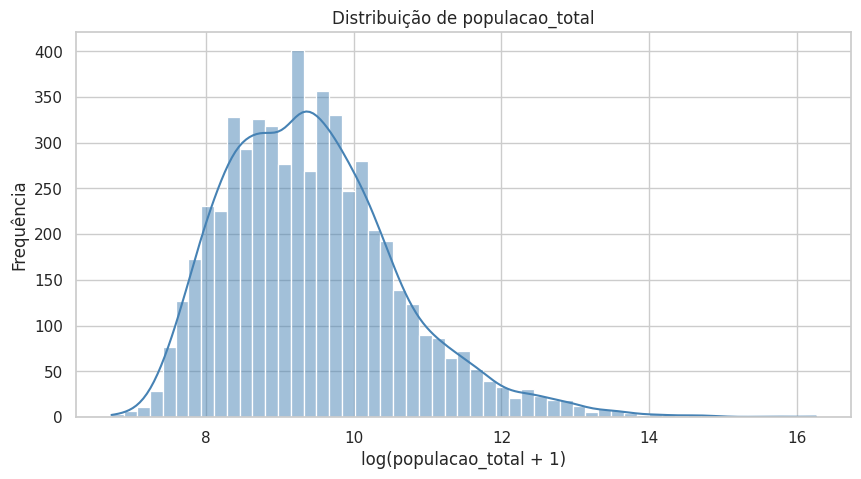

In [10]:
# Distribuição da população total (escala log)
plot_distribution(
    df, "populacao_total", log_scale=True, filename="00_populacao_total_distribuicao.png"
)
plt.show()

2026-08-26 12:22:56,155 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/figures/00_municipios_por_uf.png


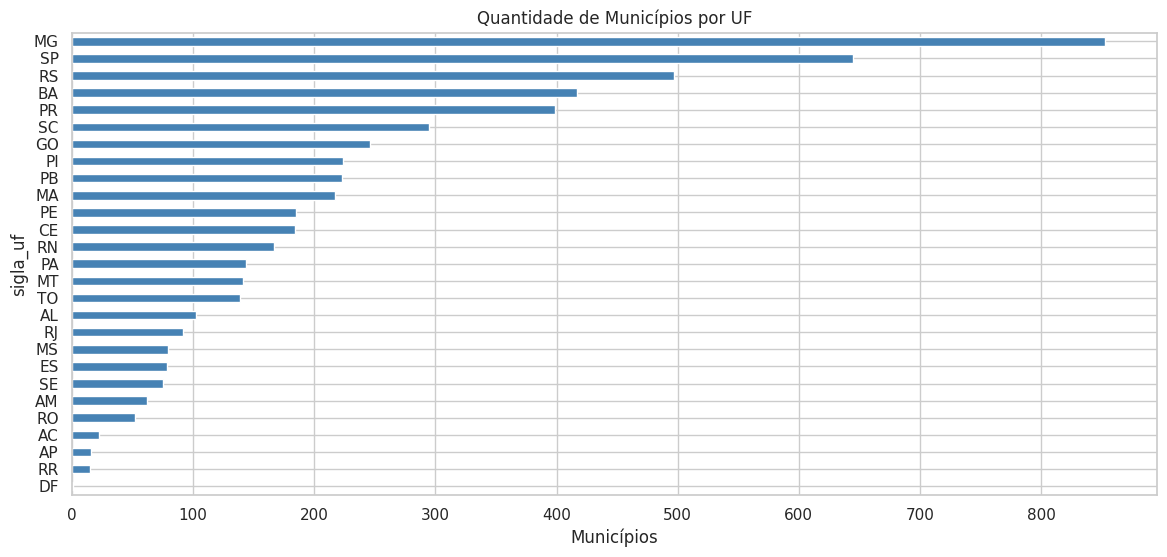

In [11]:
# Municípios por UF
fig, ax = plt.subplots(figsize=(14, 6))
uf_counts = df["sigla_uf"].value_counts().sort_values(ascending=True)
uf_counts.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Quantidade de Municípios por UF")
ax.set_xlabel("Municípios")
save_figure(fig, "00_municipios_por_uf.png")
plt.show()

## 8. Salvamento do relatório

In [12]:
report = {
    "volumetria": int(df.shape[0]),
    "colunas": int(df.shape[1]),
    "nulos_por_coluna": null_profile.set_index("coluna").to_dict(),
    "regras_negocio": rules,
    "gaps_conhecidos": gaps,
}
save_json(report, OUTPUT_REPORT)

2026-08-26 12:23:12,969 - INFO - JSON salvo em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/reports/data_quality_report.json


PosixPath('/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/reports/data_quality_report.json')

## Resumo Executivo

Este notebook gerou o relatório `data_quality_report.json`. Abaixo segue um resumo legível dos principais resultados.

In [ ]:
# Resumo legível do relatório gerado
import json
from pathlib import Path

report_path = Path("data/processed/reports/data_quality_report.json")
if report_path.exists():
    with open(report_path, "r", encoding="utf-8") as f:
        report = json.load(f)
    print(json.dumps(report, indent=2, ensure_ascii=False))
else:
    print("Relatório ainda não foi gerado.")